In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simple dataset: XOR problem (non-linear)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

In [3]:
# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# ReLU activation
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

In [4]:
np.random.seed(42)

# Input to hidden layer
W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

# Hidden to output layer
W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

In [5]:
def forward(X):
    Z1 = X.dot(W1) + b1     # Weighted sum for hidden
    A1 = relu(Z1)           # Activation
    Z2 = A1.dot(W2) + b2    # Weighted sum for output
    A2 = sigmoid(Z2)        # Activation for output
    return Z1, A1, Z2, A2

In [6]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [7]:
learning_rate = 0.1
epochs = 10000
losses = []

for i in range(epochs):
    # Forward pass
    Z1, A1, Z2, A2 = forward(X)
    
    # Compute loss
    loss = mse(y, A2)
    losses.append(loss)
    
    # Backpropagation
    dA2 = A2 - y                      # derivative of loss w.r.t output
    dZ2 = dA2 * sigmoid_derivative(Z2)
    dW2 = A1.T.dot(dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T.dot(dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # Update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    # Print every 1000 epochs
    if i % 1000 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.26164756176851484
Epoch 1000, Loss: 0.12638680626963097
Epoch 2000, Loss: 0.12540509049069226
Epoch 3000, Loss: 0.1252271735640944
Epoch 4000, Loss: 0.12516301342633518
Epoch 5000, Loss: 0.12511602288164386
Epoch 6000, Loss: 0.12509637173447188
Epoch 7000, Loss: 0.1250713780085575
Epoch 8000, Loss: 0.12506313752315623
Epoch 9000, Loss: 0.12505202346202246


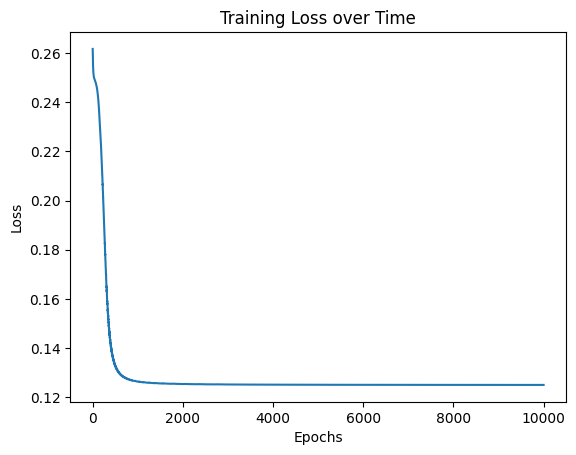

In [8]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()

In [9]:
_, _, _, A2_final = forward(X)
print("Predictions after training:")
print(A2_final)

Predictions after training:
[[0.50006507]
 [0.98947349]
 [0.50006507]
 [0.00881916]]
